En este netbook se realizara un Análisis Exploratorio de Datos (EDA) enfocado en la caracterización estructural del DataSet.  

La identificación de comportamientos relevantes para guiar preprocesamiento y construcción de módelos.

In [89]:
import pandas as pd
import numpy as np

from pathlib import Path

## 0. Ingesta de datos y configuracion de ruta

In [90]:
def cargar_archivo():
    try:

        ruta_archivo = Path.cwd().parent / "data" / "raw" / "account_profiles.csv"

        df = pd.read_csv(ruta_archivo)
        print(f"""El Dataset fue cargado exitosamente, este se compone de:\n
                    -   Columnas: {df.shape[1]}\n
                    -   Filas: {df.shape[0]}
                    """)
        return df
    
    except FileNotFoundError:
        print(f"    ERROR EN LA BUSQUEDA DEL ARCHIVO: El archivo no se encontro en: {ruta_archivo.absolute()}")
        return None
    except Exception as e:
        pritn(f"    ERROR INESPERADO: Ocurrio un error inesperado: {e}")
        return None

df = cargar_archivo()


El Dataset fue cargado exitosamente, este se compone de:

                    -   Columnas: 23

                    -   Filas: 50000
                    


## 1. Vista inicial del DataFrame

In [91]:
""" Muestra de las 10 primeras filas """
df.head(10)

,account_id,account_age_days,credit_limit,home_country,risk_score,is_high_risk,avg_txn_amount,avg_monthly_txns,has_2fa,account_type,...,max_amount,fraud_count,fraud_amount,pct_foreign,avg_velocity,unique_countries,unique_categories,avg_ip_risk,fraud_rate,is_fraudster
0,ACC0000001,353,2171.42,US,16.5,0,90.82,71.1,1,personal,...,740.46,0.0,0.00,0.35,1.27,9.0,11.0,22.98,0.000000,0.0
1,ACC0000002,2831,3031.38,US,25.4,0,63.78,7.4,1,business,...,186.13,1.0,186.13,0.50,4.00,2.0,2.0,52.45,0.500000,1.0
2,ACC0000003,2399,7533.75,US,10.6,0,72.18,31.9,0,personal,...,1175.86,0.0,0.00,0.17,1.44,3.0,8.0,15.50,0.000000,0.0
3,ACC0000004,1618,4821.94,US,20.7,0,53.64,16.6,1,personal,...,2753.31,0.0,0.00,0.33,1.11,4.0,10.0,19.01,0.000000,0.0
4,ACC0000005,1597,3355.10,US,30.6,0,168.44,32.0,1,personal,...,718.61,0.0,0.00,0.42,0.95,7.0,12.0,26.71,0.000000,0.0
5,ACC0000006,3138,2386.41,US,19.9,0,82.32,15.2,0,premium,...,1900.84,1.0,43.52,0.36,1.64,5.0,8.0,23.62,0.090909,1.0
6,ACC0000007,341,2185.13,US,7.9,0,161.14,18.6,1,personal,...,630.93,1.0,101.65,0.31,1.46,5.0,6.0,28.31,0.076923,1.0
7,ACC0000008,2554,4423.10,US,22.8,0,79.68,33.5,1,personal,...,820.73,0.0,0.00,0.30,0.87,7.0,12.0,23.74,0.000000,0.0
8,ACC0000009,759,24850.92,US,8.2,0,48.93,60.7,1,business,...,770.52,0.0,0.00,0.27,0.86,8.0,13.0,17.58,0.000000,0.0
9,ACC0000010,370,7728.18,US,28.3,0,142.22,47.2,0,personal,...,995.94,0.0,0.00,0.39,0.79,9.0,13.0,22.79,0.000000,0.0


In [92]:
# Diccionario con las traducciones
columnas_espanol = {
    'account_id': 'id_cuenta',
    'account_age_days': 'antiguedad_cuenta_dias',
    'credit_limit': 'limite_credito',
    'home_country': 'pais_origen',
    'risk_score': 'puntaje_riesgo',
    'is_high_risk': 'es_alto_riesgo',
    'avg_txn_amount': 'monto_promedio_transaccion',
    'avg_monthly_txns': 'promedio_transacciones_mensuales',
    'has_2fa': 'tiene_2fa',
    'account_type': 'tipo_cuenta',
    'total_transactions': 'total_transacciones',
    'total_amount': 'monto_total',
    'avg_amount': 'monto_promedio',
    'max_amount': 'monto_maximo',
    'fraud_count': 'cantidad_fraudes',
    'fraud_amount': 'monto_fraude',
    'pct_foreign': 'porcentaje_extranjero',
    'avg_velocity': 'velocidad_promedio',
    'unique_countries': 'paises_unicos',
    'unique_categories': 'categorias_unicas',
    'avg_ip_risk': 'riesgo_ip_promedio',
    'fraud_rate': 'tasa_fraude',
    'is_fraudster': 'es_fraudulento'
}

# Aplicar el cambio al DataFrame (asumiendo que se llama 'df')
df = df.rename(columns=columnas_espanol)

# Verificar los cambios
print(df.columns)


Index(['id_cuenta', 'antiguedad_cuenta_dias', 'limite_credito', 'pais_origen',
       'puntaje_riesgo', 'es_alto_riesgo', 'monto_promedio_transaccion',
       'promedio_transacciones_mensuales', 'tiene_2fa', 'tipo_cuenta',
       'total_transacciones', 'monto_total', 'monto_promedio', 'monto_maximo',
       'cantidad_fraudes', 'monto_fraude', 'porcentaje_extranjero',
       'velocidad_promedio', 'paises_unicos', 'categorias_unicas',
       'riesgo_ip_promedio', 'tasa_fraude', 'es_fraudulento'],
      dtype='object')


In [93]:
""" Muestra total de las filas y columnas, el tipo de datos (dtypes) de las columnas. """
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_cuenta                         50000 non-null  object 
 1   antiguedad_cuenta_dias            50000 non-null  int64  
 2   limite_credito                    50000 non-null  float64
 3   pais_origen                       50000 non-null  object 
 4   puntaje_riesgo                    50000 non-null  float64
 5   es_alto_riesgo                    50000 non-null  int64  
 6   monto_promedio_transaccion        50000 non-null  float64
 7   promedio_transacciones_mensuales  50000 non-null  float64
 8   tiene_2fa                         50000 non-null  int64  
 9   tipo_cuenta                       50000 non-null  object 
 10  total_transacciones               50000 non-null  float64
 11  monto_total                       50000 non-null  float64
 12  mont

- Integridad y completitud de los datos: El dataset cuenta con 50,000 registros y, según el conteo de Nan-Null, no presenta valores faltantes en ninguna de sus 23 columnas.

- Análisis de tipos de datos (Dtypes): La mayoria de las columnas son flooat64 e int64. Esto es excelente porque permite realizar cálculos estadísticos, matrices de correlación y aplicar modelos de Machine Learning.

- Variables categoricas: las columnas "id_cuenta", "pais_origen" y "tipo_cuenta".

    *   "id_cuentas" es un identificador único y probablemente deba ser descartado para el modelo (No aporta patrón de fraude).

    *   "pais_origen" y "tipo_cuenta" deberán ser transformadas mediante One-Hot Encoding para que el modelo pueda procesarlas.

In [94]:
df.describe()

,antiguedad_cuenta_dias,limite_credito,puntaje_riesgo,es_alto_riesgo,monto_promedio_transaccion,promedio_transacciones_mensuales,tiene_2fa,total_transacciones,monto_total,monto_promedio,monto_maximo,cantidad_fraudes,monto_fraude,porcentaje_extranjero,velocidad_promedio,paises_unicos,categorias_unicas,riesgo_ip_promedio,tasa_fraude,es_fraudulento
count,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1837.46610,6724.527119,19.912278,0.00036,79.767290,25.628144,0.648660,20.000000,3674.765273,182.978246,954.421862,0.342860,250.334682,0.293094,1.048726,4.892200,8.257020,21.556126,0.017127,0.266720
std,1045.95087,6167.105846,12.005753,0.01897,51.861165,20.152675,0.477394,16.335381,3333.278578,95.290433,861.970568,0.648564,865.803449,0.140398,0.339632,2.334757,2.992908,5.067345,0.040386,0.442249
min,30.00000,500.000000,1.000000,0.00000,6.250000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,930.00000,2861.217500,10.700000,0.00000,44.700000,12.600000,0.000000,9.000000,1443.140000,127.560000,448.000000,0.000000,0.000000,0.210000,0.860000,3.000000,6.000000,18.740000,0.000000,0.000000
50%,1841.50000,4873.655000,17.900000,0.00000,66.700000,20.100000,1.000000,16.000000,2753.275000,167.270000,750.650000,0.000000,0.000000,0.290000,1.000000,5.000000,8.000000,21.420000,0.000000,0.000000
75%,2741.00000,8387.520000,27.100000,0.00000,99.842500,32.200000,1.000000,26.000000,4847.617500,216.720000,1192.825000,1.000000,43.090000,0.370000,1.220000,6.000000,11.000000,24.170000,0.019231,1.000000
max,3649.00000,50000.000000,80.500000,1.00000,777.380000,200.000000,1.000000,185.000000,35952.160000,2529.240000,25000.000000,6.000000,25303.420000,1.000000,8.000000,11.000000,14.000000,75.400000,1.000000,1.000000


- Anomalias en montos: Se observa una alta variabilidad en "monto_maximo" ($25,000 vs media $750), lo que sugiere la presencia de outiers significativos que podrían estar vinculados a transacciones fraudulentas.

- Patrones de velocidad: La "velocidad_promedio" maxima (8.0) quintuplica la media, indicando comportamientos de ráfagas de transacciones, una conducta tipica en ataques de fuerza bruta o vaciado de cuentas.

- Perfil de seguridad: el 64.8% de la muestra utiliza 2FA. Se establece cmo hipótesis que la ausencia de esta medida es un predictor clave de la variable "es_fraudulento".

- Disercion geografica: El promedio de 5 países por cuenta sugiere un dataset con alta movilidad internacional, desde el "porcentaje_extranjero" y "riesgo_ip_promedio" serán variable criticas para el modelo.

## 2. Deteccion de valores nulos y duplicados

### 2.1 Deteccion de valores nulos

In [95]:
valores_nulos = df.isnull().sum()

print(f"Cantidad de valores nulos:\n{valores_nulos}")

Cantidad de valores nulos:
id_cuenta                           0
antiguedad_cuenta_dias              0
limite_credito                      0
pais_origen                         0
puntaje_riesgo                      0
es_alto_riesgo                      0
monto_promedio_transaccion          0
promedio_transacciones_mensuales    0
tiene_2fa                           0
tipo_cuenta                         0
total_transacciones                 0
monto_total                         0
monto_promedio                      0
monto_maximo                        0
cantidad_fraudes                    0
monto_fraude                        0
porcentaje_extranjero               0
velocidad_promedio                  0
paises_unicos                       0
categorias_unicas                   0
riesgo_ip_promedio                  0
tasa_fraude                         0
es_fraudulento                      0
dtype: int64


### 2.2 Deteccion de valores duplicados

In [96]:
valores_duplicados = df.duplicated().sum()

print(f"Cantidad de valores duplicados: {valores_duplicados}")

Cantidad de valores duplicados: 0


Se comprobo que no existen valores duplicados o nulos dentro del dataset, no se requiere realizar ningun codigo para limpiarlo

## 3. Análisis Exploratorio (EDA) - "Buscando el crimen"

### 3.1 Análisis de correlacion

In [97]:
correlacion = df.select_dtypes(['int', 'float']).corr()
display(correlacion.round(3))

,antiguedad_cuenta_dias,limite_credito,puntaje_riesgo,es_alto_riesgo,monto_promedio_transaccion,promedio_transacciones_mensuales,tiene_2fa,total_transacciones,monto_total,monto_promedio,monto_maximo,cantidad_fraudes,monto_fraude,porcentaje_extranjero,velocidad_promedio,paises_unicos,categorias_unicas,riesgo_ip_promedio,tasa_fraude,es_fraudulento
antiguedad_cuenta_dias,1.000,-0.005,0.006,0.002,0.006,-0.002,0.003,-0.005,-0.005,-0.004,-0.004,-0.012,-0.005,-0.003,-0.005,-0.006,-0.005,-0.004,-0.015,-0.013
limite_credito,-0.005,1.000,-0.007,-0.008,-0.003,-0.002,-0.006,-0.003,-0.005,-0.004,-0.002,-0.006,-0.005,0.002,-0.000,0.000,-0.001,-0.004,-0.006,-0.009
puntaje_riesgo,0.006,-0.007,1.000,0.084,-0.004,-0.002,-0.002,-0.003,-0.001,0.004,0.005,0.001,0.003,-0.004,-0.004,-0.002,0.001,0.003,0.001,-0.000
es_alto_riesgo,0.002,-0.008,0.084,1.000,0.008,-0.002,-0.004,-0.002,-0.001,-0.002,-0.002,0.018,0.005,0.006,0.001,-0.003,-0.004,0.015,0.026,0.010
monto_promedio_transaccion,0.006,-0.003,-0.004,0.008,1.000,-0.002,0.006,-0.004,-0.004,0.002,-0.001,-0.007,-0.002,-0.005,-0.006,-0.005,-0.004,-0.001,-0.002,-0.003
promedio_transacciones_mensuales,-0.002,-0.002,-0.002,-0.002,-0.002,1.000,-0.002,0.962,0.870,0.008,0.350,0.416,0.230,0.011,0.006,0.746,0.727,0.011,0.001,0.335
tiene_2fa,0.003,-0.006,-0.002,-0.004,0.006,-0.002,1.000,-0.003,-0.011,-0.017,-0.018,-0.073,-0.042,0.008,-0.020,0.002,0.005,-0.009,-0.057,-0.063
total_transacciones,-0.005,-0.003,-0.003,-0.002,-0.004,0.962,-0.003,1.000,0.905,0.010,0.371,0.432,0.241,0.010,0.006,0.787,0.775,0.012,0.000,0.352
monto_total,-0.005,-0.005,-0.001,-0.001,-0.004,0.870,-0.011,0.905,1.000,0.322,0.647,0.482,0.449,0.013,0.030,0.714,0.745,0.029,0.070,0.396
monto_promedio,-0.004,-0.004,0.004,-0.002,0.002,0.008,-0.017,0.010,0.322,1.000,0.651,0.156,0.390,0.029,0.080,0.020,0.101,0.082,0.210,0.164


1. Los "Delatadores" del fraude (Correlaciones Fuertes): Estas son las variables que más "pesan" a la hora de identificar a un estafador.

    - cantidad_fraudes (0.87): Esta es la correlación más alta. Es obio, pero confirma que el dataset es consistente: A mas eventos de fraude detectados, más alta es la probabilidad de que la cuenta sea marcada como "es_fraudulento".
    - "tasa_fraude" (0.70): Al igual que la anterior, es un predicator directo.
    - "monto_fraude" (0.47): Existe una relación moderada-fuerte. Esto indica que el fraude no solo se trata de cuántas veces roban, sino  de cuanto dinero mueven.

2. Comportamiento Operativo (Correlaciones moderadas):

    -"monto_total" (0.39) y "total_transacciones" (0.35): Los estafadores en este dataset parecen tener una actividad mucho mas alta que el usuario promedio. (El fraude no es un evento aislado de un solo "golpe", sino que un volumen alto de transacciones).

    - "paises_unicos" (0.33) y "categorias_unicas" (0.32): Los estafadores tienden a diversificar. Operan en más paises y compran en más categorias distintas que un usuario normal.

    - "monto_maximo" (0.32): Los picos de gasto (esos $25,000 que vimos antes) estan correlacionados con el fraude

3. La defensa (Correlaciones Negativas): Esto reduce la probabilidad de fraude.

    - "tiene_2fa"(-0.06): Es una correlacion negativa. Aunque el número parece pequeño, el signo menos dice: A mayor seguridad (2FA), menor probabilidad de fraude

### Tras analizar las correlaciones respecto a la variable objetivo:

    1. Predictores directos: Existe una correlación casi perfecta con "cantidad_fraudes" (0.87%) y "tasas_fraude"(0.70%), lo cual valida la integridad de las etiquetas del dataset.

    2. Perfil transaccional: El fraude está estrechamente ligado al volumen. Variables como "monto_total" (0.39) y "tasa_transacciones" (0.35) sugieren que las cuentas fraudulentas presentan una actividad inusualmente alta.

    3. Dispersión geografica: La correlación positiva con "paises_unicos" (0.33) indica que el uso de la cuenta en multiples jurisdicciones es un sintoma claro de riesgo.

    4. Eficacia de seguridad: Se observa una correlacion negativa con "tiene_2fa". Aunque leve, confirma que cuentas con doble factor de autentificación tiene menor indice de fraude.

### 3.2 Grafico de dispersión (Scatter Plot)

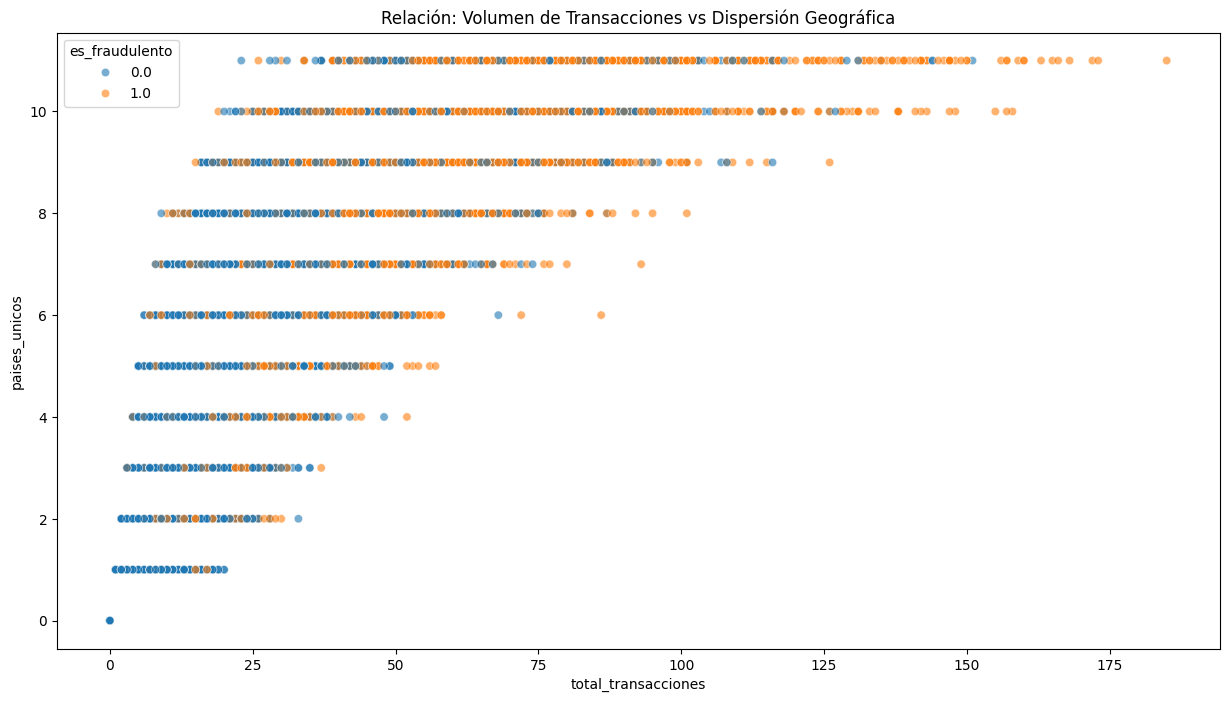

In [98]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

sns.scatterplot(data = df, x='total_transacciones', y= 'paises_unicos', hue='es_fraudulento', alpha=0.6)

plt.title('Relación: Volumen de Transacciones vs Dispersión Geográfica')

plt.show()

El fraude en este sistema no es quirúrgico, es masivo. Los estafadores operan con un volumen de transacciones significativamente mayor al del usuario promedio y con una dispersión geográfica alta.

Se recomienda implementar una regla de "Velocity Check" (Control de velocidad). Si una cuenta supera las 40 transacciones o los 7 países en un periodo corto, debe saltar una alerta naranja automatica.

## 3.2 Boxplot de "Monto maximo"

### 3.3 ¿Sirve el 2FA?

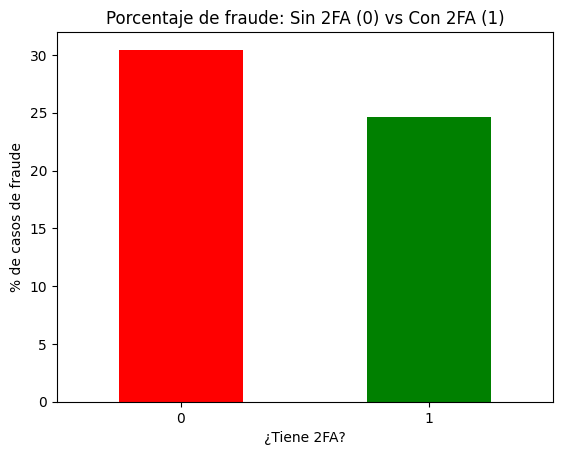

In [99]:
# Columno el procentaje de fraude según si tienen 2FA o no
df_2fa = df.groupby('tiene_2fa')['es_fraudulento'].mean() * 100

df_2fa.plot(kind='bar', color=['red', 'green'])
plt.title("Porcentaje de fraude: Sin 2FA (0) vs Con 2FA (1)")

plt.ylabel("% de casos de fraude")
plt.xticks(rotation= 0)
plt.xlabel("¿Tiene 2FA?")
plt.show()

## 4. Outliers (Valores atipicos)

### 4.1 Calculo de los putliers

In [100]:
# Variables clave según la correlación de fraude

variables_analisis = ['monto_total', 'total_transacciones', 'velocidad_promedio', 'puntaje_riesgo']

# Calculo los quintiles (divisiones de 20% en 20%)
quintiles_limites = df[variables_analisis].quantile([0.2, 0.4, 0.6, 0.8])

print(quintiles_limites)

     monto_total  total_transacciones  velocidad_promedio  puntaje_riesgo
0.2     1193.762                  8.0                0.81             9.2
0.4     2194.214                 13.0                1.00            14.9
0.6     3431.888                 19.0                1.10            21.1
0.8     5521.866                 29.0                1.27            29.7


In [101]:
# Creacion de segmentación por quintiles para el Monto Total:
df['segmento_gasto'] = pd.qcut(df['monto_total'], q=5, labels= ['Muy bajo', 'bajo', 'Medio', 'Alto', 'Muy alto'])

# Calculo de tasa de fraude promedio para cada segmento
tasa_fraude_quintil = df.groupby('segmento_gasto')['es_fraudulento'].mean() * 100

print(tasa_fraude_quintil)

segmento_gasto
Muy bajo     7.19
bajo        14.69
Medio       22.55
Alto        32.64
Muy alto    56.29
Name: es_fraudulento, dtype: float64


/tmp/ipykernel_34148/3585992368.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_fraude_quintil = df.groupby('segmento_gasto')['es_fraudulento'].mean() * 100


/tmp/ipykernel_34148/2727972096.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa_fraude_quintil.index, y=tasa_fraude_quintil.values, palette='Reds')


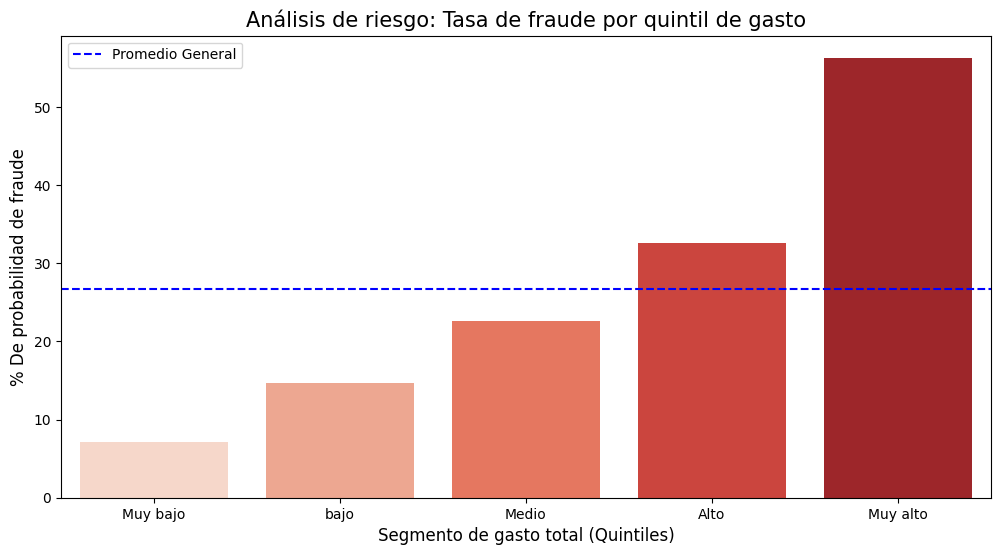

In [102]:
plt.figure(figsize=(12, 6))
sns.barplot(x=tasa_fraude_quintil.index, y=tasa_fraude_quintil.values, palette='Reds')

plt.title("Análisis de riesgo: Tasa de fraude por quintil de gasto", fontsize=15)
plt.xlabel("Segmento de gasto total (Quintiles)", fontsize=12)
plt.ylabel("% De probabilidad de fraude", fontsize = 12)
plt.axhline(df['es_fraudulento'].mean() * 100, color= 'blue', linestyle='--', label='Promedio General')
plt.legend()
plt.show()

- El quintil 5 (Muy alto): Si este segmento tiene una tasa de fraude muy superior al promedio general (la linea azul), significa que el fraude está concentrado en transacciones de alto volumen.

- La pendiente: Si el grafico sube como una escalera, el comportamiento de gasto es un predictor lineal muy fuerte para el futuro modelo

Los estafadores tienen un "Ticket Máximo" muchos más elevado. Mientras el usuario normal se mantiene en un rango controlado, el fraude busca "reventar" el limite de crédito en pocos movimientos.

Idea: El sistema de detección actual parece permitir transacciones de alto valor demasiado fácil. Se deberia bajar el umbral de verificación de identidad para montos que superen el procentil 75 del gasto historico del usuario.

## 5. Diagnostico de desequilibrio (Balance de clases)

/tmp/ipykernel_34148/1892124666.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='es_fraudulento', data=df, palette='viridis')


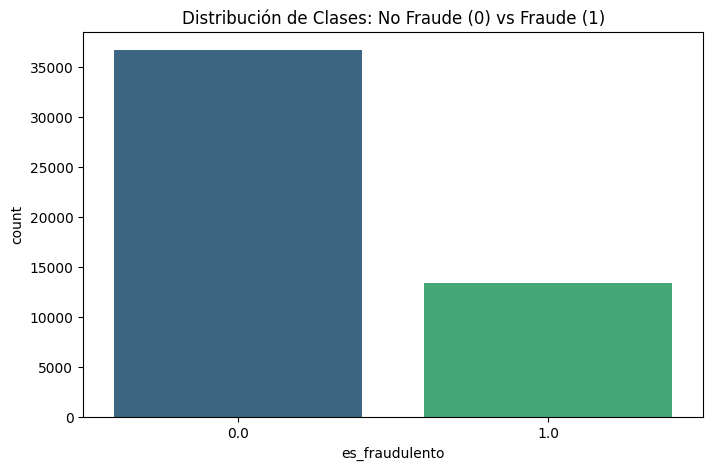

In [103]:
plt.figure(figsize=(8,5))
sns.countplot(x='es_fraudulento', data=df, palette='viridis')
plt.title('Distribución de Clases: No Fraude (0) vs Fraude (1)')
plt.show()

# Nota: El dataset presenta un 26.6% de casos de fraude, lo que indica una muestra balanceada
# artificialmente para entrenamiento

### 5.2 Análisis de sesgo (Skewness) en los montos

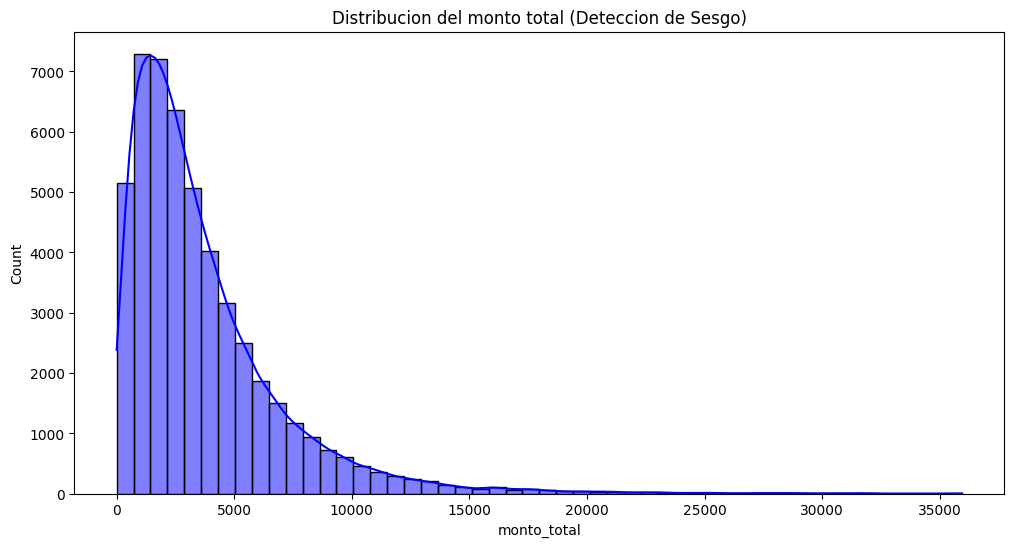

In [106]:
plt.figure(figsize=(12, 6))
sns.histplot(df['monto_total'], kde=True, color='blue', bins=50)
plt.title('Distribucion del monto total (Deteccion de Sesgo)')
plt.show()

### 5.3 Detección de redundancia (Multicolinealidad)

In [ ]:
# Esto es vital para no "confundir" al modelo con informacion repetida

# Busco variables con correlación mayor a 0.90
correlaciones = df.select_dtypes(include='nuber').corr()

TypeError: DataFrame.select_dtypes() got an unexpected keyword argument 'incluide'